Poniżej masz wersję **w Markdown, ale z kodami w Pythonie**. Oparłem ją o bibliotekę **scikit-fda**, która udostępnia klasy `ConstantBasis`, `MonomialBasis`, `FourierBasis` i `BSplineBasis`, czyli bezpośrednie odpowiedniki baz znanych z R. Obiekt reprezentacji bazowej danych funkcjonalnych w Pythonie to `FDataBasis`. W dokumentacji scikit-fda baza Fouriera ma zawsze nieparzystą liczbę funkcji bazowych — jeśli podasz liczbę parzystą, zostanie automatycznie zwiększona o 1. Dokumentacja potwierdza też, że `BSplineBasis` używa parametrów `domain_range`, `n_basis`, `order` i `knots`, a obiekty baz mają metody `plot()` oraz obsługę pochodnych. ([fda.readthedocs.io][1])

---

# Funkcje tworzące bazy w Pythonie

W Pythonie, przy użyciu biblioteki `scikit-fda`, można definiować różne systemy bazowe funkcji. Odpowiedniki najważniejszych baz z R są następujące:

```python
from skfda.representation.basis import (
    ConstantBasis,
    MonomialBasis,
    FourierBasis,
    BSplineBasis,
)
```

Przykładowe tworzenie obiektów bazowych:

```python
basisobj = ConstantBasis(domain_range=(0, 1))
basisobj = MonomialBasis(domain_range=(0, 1), n_basis=4)
basisobj = FourierBasis(domain_range=(0, 1), n_basis=5, period=1)
basisobj = BSplineBasis(domain_range=(0, 1), n_basis=10, order=4)
```

Jeśli chcemy reprezentować konkretną funkcję lub zbiór funkcji w zadanej bazie, używamy obiektu `FDataBasis`. ([fda.readthedocs.io][2])

---

## Najczęściej używane argumenty

* `domain_range` – zakres argumentu ( t ), odpowiednik `rangeval` w R; najczęściej para `(a, b)`
* `n_basis` – liczba funkcji bazowych ( K )
* `order` – rząd splajnu B-spline
* `knots` – wektor węzłów
* `period` – okres bazy Fouriera

Przykład przedziału jednostkowego:

```python
domain_range = (0, 1)
```

---

# Baza Fouriera

## Przykład

Poniższy kod tworzy bazę Fouriera z ( K = 65 ) funkcjami bazowymi na przedziale ([0, 365]) i z okresem równym 365:

```python
from skfda.representation.basis import FourierBasis

daybasis65 = FourierBasis(domain_range=(0, 365), n_basis=65, period=365)
```

Jeśli nie podamy `period`, to jest on powiązany z zakresem dziedziny. Dodatkowo dokumentacja scikit-fda podaje, że liczba funkcji bazowych w bazie Fouriera jest zawsze nieparzysta; gdy podamy wartość parzystą, biblioteka automatycznie zwiększy ją o 1. ([fda.readthedocs.io][3])

---

## Rysowanie bazy Fouriera

```python
daybasis65.plot()
```

---

## Baza Fouriera bez wyrazu stałego

W R można było używać `dropind=1`. W Pythonie nie ma tu dokładnie tej samej składni, więc najprościej jest po prostu utworzyć bazę z odpowiednią liczbą funkcji i pamiętać, że w dalszych obliczeniach nie chcemy używać pierwszej funkcji bazowej, albo ręcznie zbudować własny układ funkcji. To jest jedna z różnic między `fda` w R a `scikit-fda` w Pythonie. Dokumentacja scikit-fda potwierdza klasy bazowe i ich parametry, ale nie opisuje odpowiednika `dropind` dla `FourierBasis`. ([fda.readthedocs.io][2])

---

# Zadanie 1 – B-splajny

## Utworzenie 13 B-splajnów rzędu czwartego na przedziale ([0,10])

```python
from skfda.representation.basis import BSplineBasis

splinebasis = BSplineBasis(domain_range=(0, 10), n_basis=13, order=4)
splinebasis.plot()
```

Dokumentacja `BSplineBasis` wskazuje, że `order=4` oznacza splajny stopnia trzeciego, czyli klasyczne splajny sześcienne. ([fda.readthedocs.io][4])

---

## Narysowanie pojedynczej funkcji bazowej

Tu trzeba uważać: w Pythonie nie zawsze zadziała indeksowanie dokładnie tak samo jak w R typu `basis[6]`. Najpewniejsza droga to ewaluacja wszystkich funkcji bazowych na siatce punktów i wybranie jednej kolumny do narysowania.

```python
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(0, 10, 1000)
values = splinebasis(grid)[..., 0]   # wartości funkcji bazowych na siatce

plt.plot(grid, values[:, 5])  # 6. funkcja bazowa, bo indeksowanie od 0
plt.title("6. funkcja bazowa B-spline")
plt.xlabel("t")
plt.ylabel("wartość")
plt.show()
```

To podejście jest praktyczniejsze niż ślepe kopiowanie składni z R. Sama dokumentacja potwierdza, że obiekty baz można ewaluować i rysować. ([fda.readthedocs.io][5])

---

## Komentarz do własności

Dla B-splajnów rzędu czwartego funkcja bazowa jest niezerowa tylko lokalnie, na ograniczonej liczbie sąsiednich podprzedziałów. Wynika to z definicji rekurencyjnej B-splajnów i ich lokalnego nośnika. Dokumentacja scikit-fda opisuje tę definicję i sposób budowy na węzłach. ([fda.readthedocs.io][4])

---

In [3]:
from skfda.representation.basis import (
    ConstantBasis,
    MonomialBasis,
    FourierBasis,
    BSplineBasis,
)

In [4]:
from skfda.representation.basis import FourierBasis

daybasis65 = FourierBasis(domain_range=(0, 365), n_basis=65, period=365)

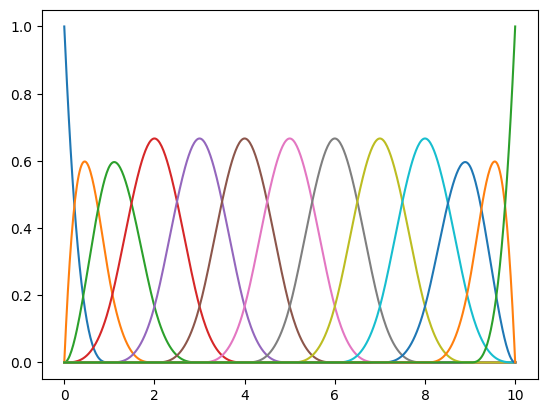

In [6]:
from skfda.representation.basis import BSplineBasis

splinebasis = BSplineBasis(domain_range=(0, 10), n_basis=13, order=4)
splinebasis.plot()

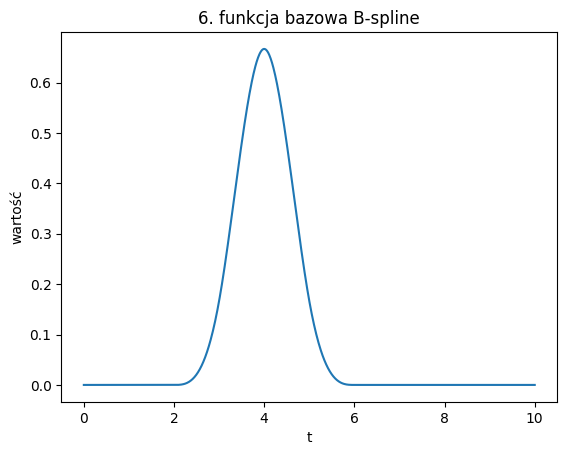

In [8]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(0, 10, 1000)
values = splinebasis(grid)[..., 0]   # wartości funkcji bazowych na siatce

# values has shape (n_basis, n_points), so select the 6th basis as values[5, :]
plt.plot(grid, values[5, :])  # 6. funkcja bazowa, bo indeksowanie od 0
plt.title("6. funkcja bazowa B-spline")
plt.xlabel("t")
plt.ylabel("wartość")
plt.show()

# Zadanie 2 – różne rzędy splajnów

## Tworzenie baz

```python
import numpy as np
from skfda.representation.basis import BSplineBasis

basis2 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=5, order=2)
basis3 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=6, order=3)
basis4 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=7, order=4)
```

## Rysowanie

```python
basis2.plot()
basis3.plot()
basis4.plot()
```

---

## Baza z tymi samymi lokalizacjami węzłów, ale rzędu 6

Tu trzeba być ostrożnym: jeśli chcesz zachować dokładnie te same węzły, najlepiej jawnie je podać przez argument `knots`, zamiast liczyć, że sama liczba funkcji bazowych wszystko ustawi identycznie.

```python
knots = np.linspace(0, 2*np.pi, 4)  # przykład
basis6 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=9, order=6, knots=knots)
basis6.plot()
```

To jest ważne, bo przy B-splajnach relacja między `n_basis`, `order` i `knots` nie jest czymś, co warto zgadywać na pamięć — lepiej jawnie kontrolować węzły. Dokumentacja potwierdza, że `knots` można przekazać bezpośrednio. ([fda.readthedocs.io][4])

---

## Nierównomiernie rozmieszczone węzły

```python
knotvec = [0, 1, 2, 4, 7, 10]

basis_irregular = BSplineBasis(
    domain_range=(0, 10),
    n_basis=8,
    order=4,
    knots=knotvec
)

basis_irregular.plot()
```

---

In [9]:
import numpy as np
from skfda.representation.basis import BSplineBasis

basis2 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=5, order=2)
basis3 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=6, order=3)
basis4 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=7, order=4)

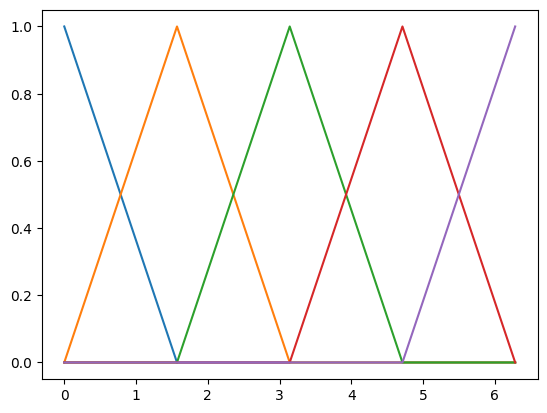

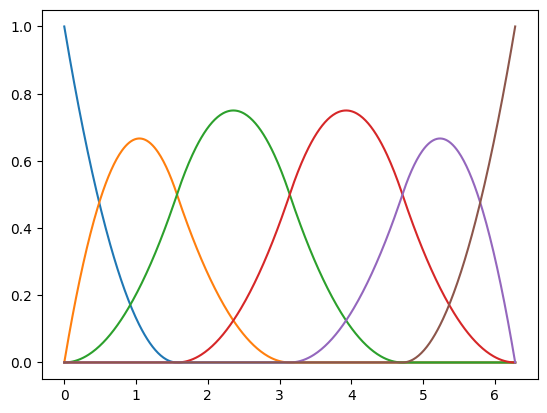

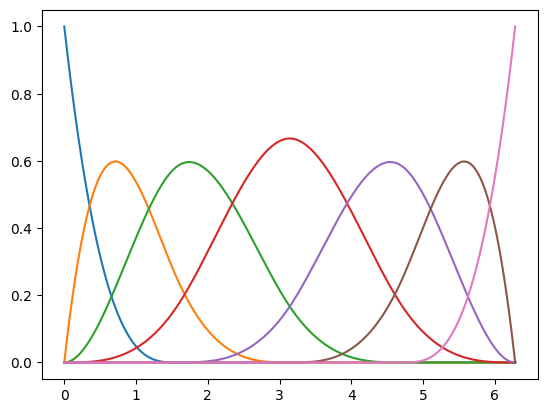

In [10]:
basis2.plot()
basis3.plot()
basis4.plot()

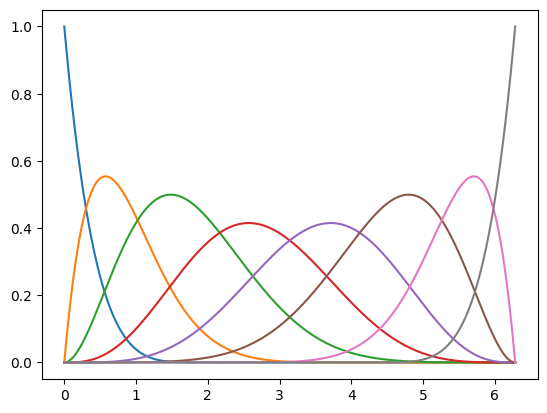

In [12]:
knots = np.linspace(0, 2*np.pi, 4)  # przykład
# For BSplineBasis: n_basis = order + len(knots) - 2
# order=6, len(knots)=4 -> n_basis should be 8
basis6 = BSplineBasis(domain_range=(0, 2*np.pi), n_basis=8, order=6, knots=knots)
basis6.plot()

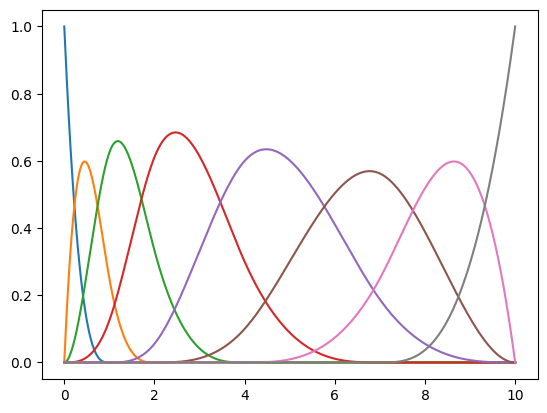

In [13]:
knotvec = [0, 1, 2, 4, 7, 10]

basis_irregular = BSplineBasis(
    domain_range=(0, 10),
    n_basis=8,
    order=4,
    knots=knotvec
)

basis_irregular.plot()

# Zadanie 3 – inne bazy

## Baza stała na ([0,1])

```python
from skfda.representation.basis import ConstantBasis

conbasis = ConstantBasis(domain_range=(0, 1))
conbasis.plot()
```

## Baza jednomianowa stopnia 3 na ([0,1])

```python
from skfda.representation.basis import MonomialBasis

monbasis = MonomialBasis(domain_range=(0, 1), n_basis=4)
monbasis.plot()
```

Taka baza odpowiada funkcjom:
[
1,; t,; t^2,; t^3
]
co jest zgodne z ideą `MonomialBasis` w scikit-fda. ([fda.readthedocs.io][1])

---

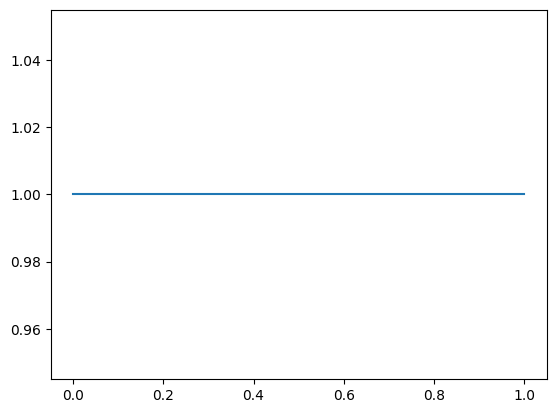

In [14]:
from skfda.representation.basis import ConstantBasis

conbasis = ConstantBasis(domain_range=(0, 1))
conbasis.plot()

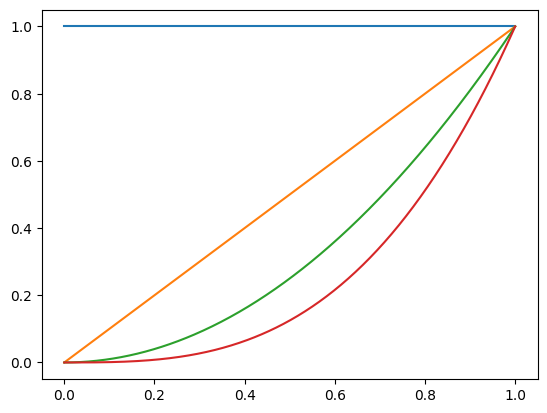

In [15]:
from skfda.representation.basis import MonomialBasis

monbasis = MonomialBasis(domain_range=(0, 1), n_basis=4)
monbasis.plot()

# Zadanie 4 – wygenerowanie bazy B-splajnów

## Krok 1 – wybór zakresu

```python
domain_range = (0, 1)
```

## Krok 2 – wybór rzędu

```python
order = 4
```

## Krok 3 – liczba funkcji bazowych

```python
n_basis = 23
```

## Krok 4 – utworzenie bazy

```python
from skfda.representation.basis import BSplineBasis

basis = BSplineBasis(domain_range=domain_range, n_basis=n_basis, order=order)
```

## Krok 5 – rysowanie

```python
basis.plot()
```

---

## Pochodne bazy

W scikit-fda obiekty baz mają obsługę pochodnych. Dokumentacja bazowej klasy `Basis` podaje metody związane z pochodnymi, w tym `derivative`. ([fda.readthedocs.io][5])

Przykład praktyczny:

```python
basis_der1 = basis.derivative(order=1)
basis_der2 = basis.derivative(order=2)

basis_der1.plot()
basis_der2.plot()
```

---

## Alternatywnie: ręczne rysowanie pochodnych na siatce

Jeżeli chcesz mieć większą kontrolę nad wykresem:

```python
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(0, 1, 1000)

vals0 = basis(grid)[..., 0]
vals1 = basis.derivative(order=1)(grid)[..., 0]
vals2 = basis.derivative(order=2)(grid)[..., 0]

plt.figure(figsize=(10, 4))
for i in range(vals0.shape[1]):
    plt.plot(grid, vals0[:, i])
plt.title("Baza B-splajnów")
plt.show()

plt.figure(figsize=(10, 4))
for i in range(vals1.shape[1]):
    plt.plot(grid, vals1[:, i])
plt.title("Pierwsze pochodne funkcji bazowych")
plt.show()

plt.figure(figsize=(10, 4))
for i in range(vals2.shape[1]):
    plt.plot(grid, vals2[:, i])
plt.title("Drugie pochodne funkcji bazowych")
plt.show()
```

---

# Minimalny import do całego zestawu

```python
import numpy as np
import matplotlib.pyplot as plt

from skfda.representation.basis import (
    ConstantBasis,
    MonomialBasis,
    FourierBasis,
    BSplineBasis,
)
```

---

In [18]:
domain_range = (0, 1)
order = 4
n_basis = 23

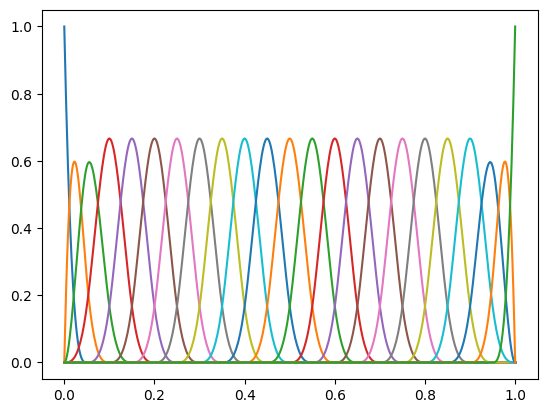

In [20]:
from skfda.representation.basis import BSplineBasis

basis = BSplineBasis(domain_range=domain_range, n_basis=n_basis, order=order)
basis.plot()

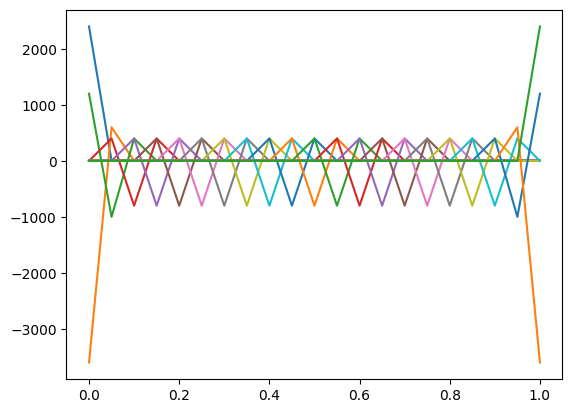

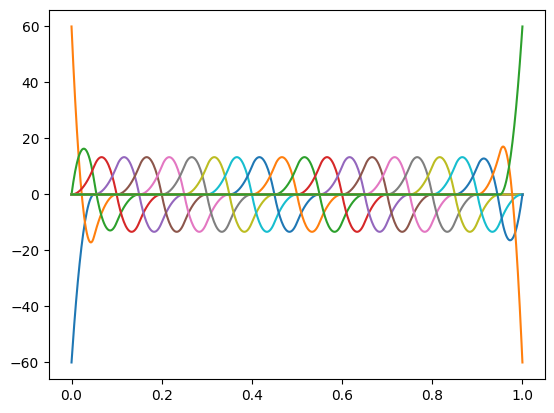

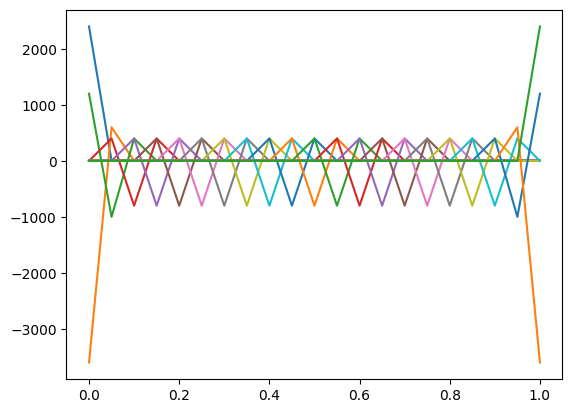

In [21]:
basis_der1 = basis.derivative(order=1)
basis_der2 = basis.derivative(order=2)

basis_der1.plot()
basis_der2.plot()

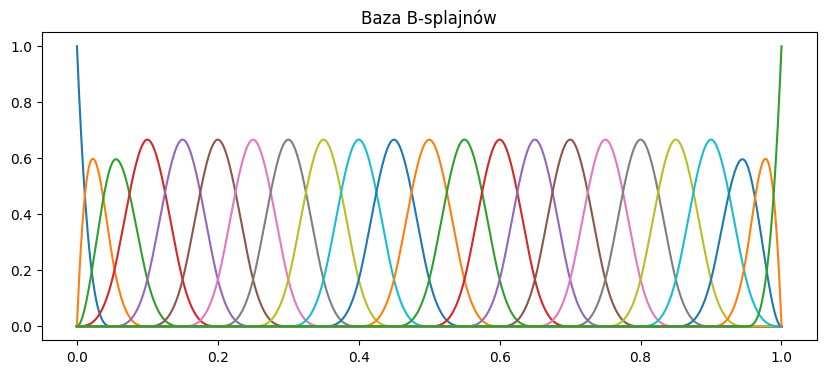

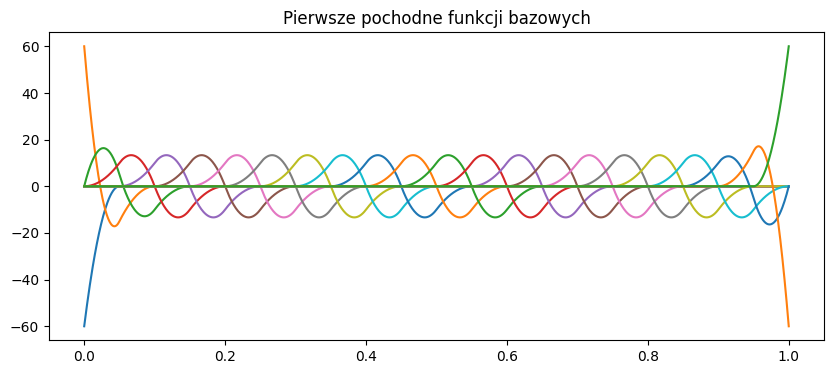

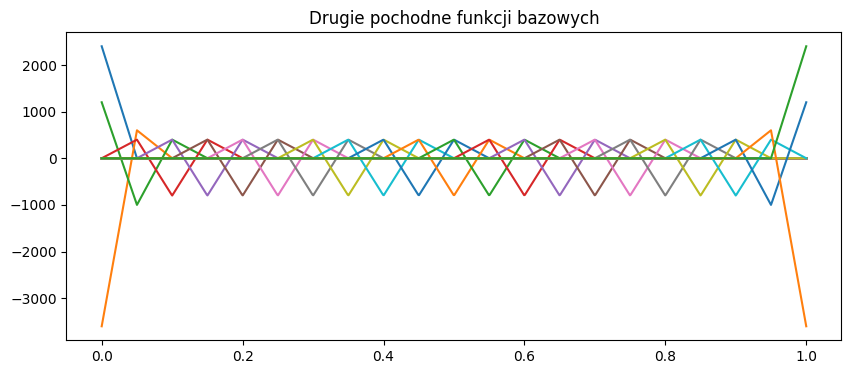

In [23]:
# create grid (np is already imported in other cells)
grid = np.linspace(0, 1, 1000)

vals0 = basis(grid)[..., 0]
vals1 = basis.derivative(order=1)(grid)[..., 0]
vals2 = basis.derivative(order=2)(grid)[..., 0]

# Ensure arrays have shape (n_points, n_basis). Depending on scikit-fda version
# evaluation may return (n_basis, n_points) or (n_points, n_basis).
def to_point_basis_array(arr):
    if arr.shape[0] == grid.shape[0]:
        return arr
    if arr.shape[1] == grid.shape[0]:
        return arr.T
    raise ValueError(f"Unexpected shape {arr.shape} for grid length {grid.shape[0]}")

vals0_plot = to_point_basis_array(vals0)
vals1_plot = to_point_basis_array(vals1)
vals2_plot = to_point_basis_array(vals2)

plt.figure(figsize=(10, 4))
for i in range(vals0_plot.shape[1]):
    plt.plot(grid, vals0_plot[:, i])
plt.title("Baza B-splajnów")
plt.show()

plt.figure(figsize=(10, 4))
for i in range(vals1_plot.shape[1]):
    plt.plot(grid, vals1_plot[:, i])
plt.title("Pierwsze pochodne funkcji bazowych")
plt.show()

plt.figure(figsize=(10, 4))
for i in range(vals2_plot.shape[1]):
    plt.plot(grid, vals2_plot[:, i])
plt.title("Drugie pochodne funkcji bazowych")
plt.show()

In [25]:
import pandas as pd

In [57]:
df = pd.read_csv("wig20_d.csv", parse_dates=True)
df.columns = ['Date','Open', 'High', 'Low', 'Close', 'Volume']
df["Date"] = pd.to_datetime(df["Date"])
# df.head()
df = df.sort_values("Date").reset_index(drop=True)

df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df = df.dropna(subset=["Close"])
print(df.head())

        Date   Open   High    Low  Close   Volume
0 1991-04-16  100.0  100.0  100.0  100.0    325.0
1 1991-04-23   95.7   95.7   95.7   95.7   5905.0
2 1991-04-30   93.5   93.5   93.5   93.5   7162.0
3 1991-05-14   92.9   92.9   92.9   92.9  18300.0
4 1991-05-21   95.5   95.5   95.5   95.5  14750.0


In [43]:
df["year_month"] = df["Date"].dt.to_period("M")
df["day_in_month"] = df.groupby("year_month").cumcount()

In [44]:
def resample_curve(y, n_points=20):
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, n_points)
    return np.interp(x_new, x_old, y)

curves = []
labels = []

for period, g in df.groupby("year_month"):
    y = g["Close"].values
    
    # pomijamy bardzo krótkie miesiące
    if len(y) < 10:
        continue
    
    # normalizacja: start miesiąca = 0
    y_norm = y / y[0] - 1
    
    y_resampled = resample_curve(y_norm, n_points=20)
    curves.append(y_resampled)
    labels.append(str(period))

curves = np.array(curves)
print(curves.shape)  # (liczba_miesięcy, 20)

(399, 20)


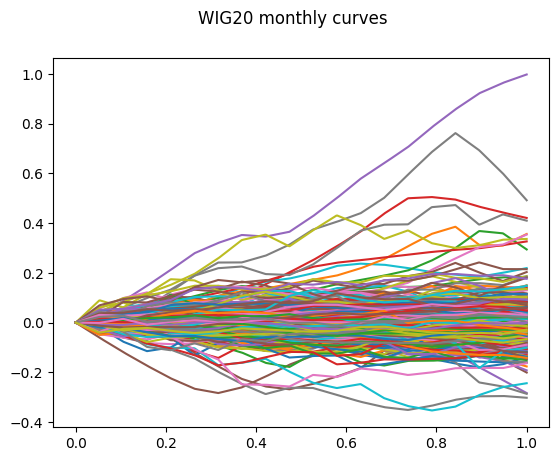

In [45]:
import skfda
from skfda import FDataGrid

grid_points = np.linspace(0, 1, 20)

fd = FDataGrid(
    data_matrix=curves,
    grid_points=grid_points,
    sample_names=labels,
    dataset_name="WIG20 monthly curves"
)

fd.plot()
plt.show()

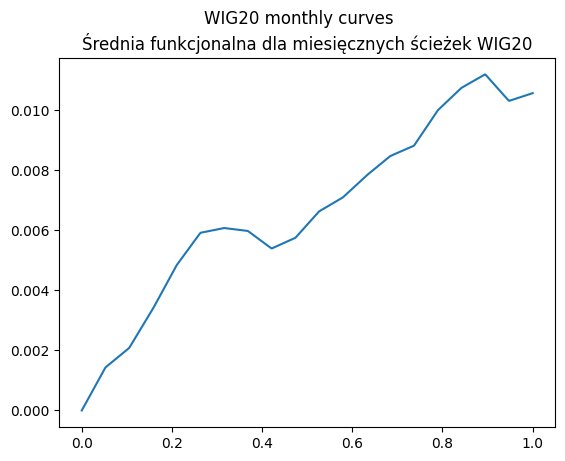

In [46]:
mean_fd = fd.mean()
mean_fd.plot()
plt.title("Średnia funkcjonalna dla miesięcznych ścieżek WIG20")
plt.show()

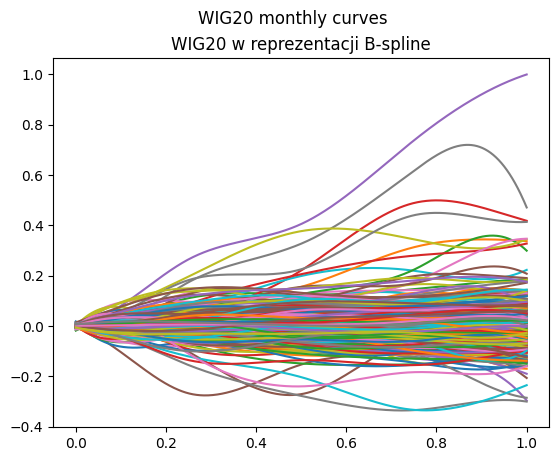

In [51]:
from skfda.representation.basis import BSplineBasis

basis = BSplineBasis(domain_range=(0, 1), n_basis=7, order=4)
fd_basis = fd.to_basis(basis)

fd_basis.plot()
plt.title("WIG20 w reprezentacji B-spline")
plt.show()

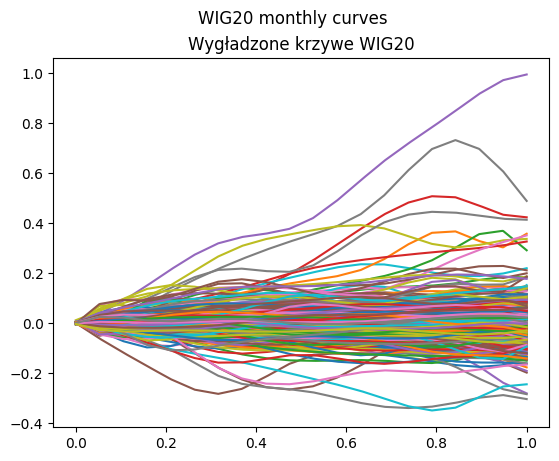

In [52]:
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import BSplineBasis

basis = BSplineBasis(domain_range=(0, 1), n_basis=9, order=4)
smoother = BasisSmoother(basis=basis)

fd_smooth = smoother.fit_transform(fd)

fd_smooth.plot()
plt.title("Wygładzone krzywe WIG20")
plt.show()

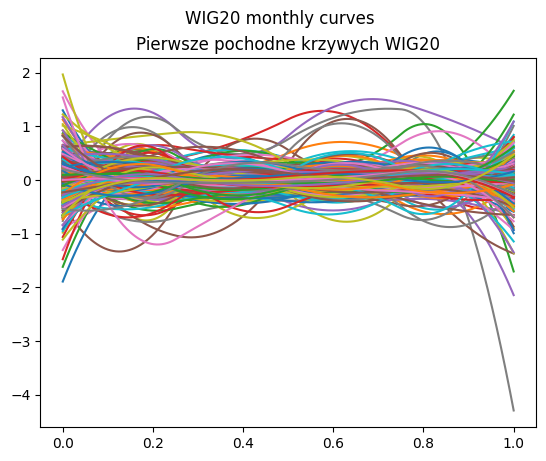

In [53]:
fd_basis_deriv = fd_basis.derivative(order=1)
fd_basis_deriv.plot()
plt.title("Pierwsze pochodne krzywych WIG20")
plt.show()

In [54]:
from skfda.preprocessing.dim_reduction import FPCA

fpca = FPCA(n_components=3)
scores = fpca.fit_transform(fd)

print(scores.shape)   # liczba_obserwacji x liczba_skladowych

(399, 3)


In [55]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scores)

result = pd.DataFrame({
    "month": labels,
    "cluster": clusters
})

print(result.head(20))

      month  cluster
0   1993-01        0
1   1993-02        1
2   1993-03        0
3   1993-04        2
4   1993-05        2
5   1993-06        1
6   1993-07        0
7   1993-08        2
8   1993-09        1
9   1993-10        0
10  1993-11        0
11  1993-12        2
12  1994-01        0
13  1994-02        2
14  1994-03        1
15  1994-04        1
16  1994-05        0
17  1994-06        1
18  1994-07        2
19  1994-08        0


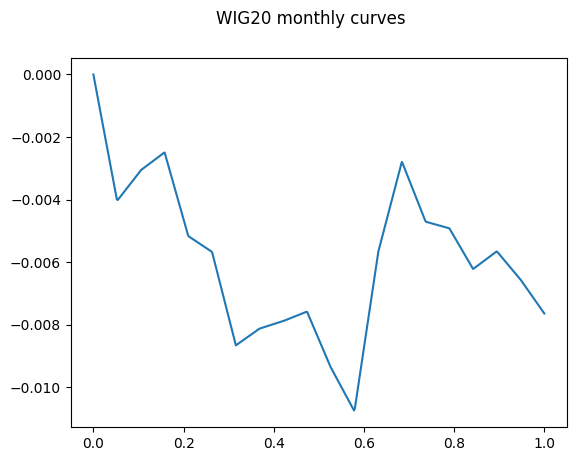

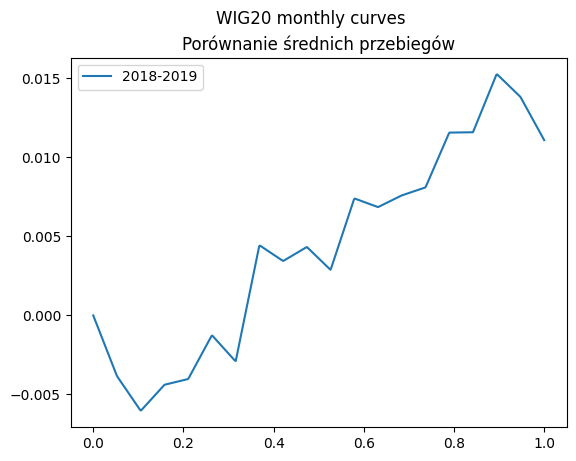

In [56]:
label_series = pd.Series(labels)

mask_old = label_series.str.startswith(("2018", "2019"))
mask_new = label_series.str.startswith(("2024", "2025"))

fd_old = fd[mask_old.values]
fd_new = fd[mask_new.values]

fd_old.mean().plot()
fd_new.mean().plot()
plt.legend(["2018-2019", "2024-2025"])
plt.title("Porównanie średnich przebiegów")
plt.show()

        Date   Open   High    Low  Close   Volume
0 1991-04-16  100.0  100.0  100.0  100.0    325.0
1 1991-04-23   95.7   95.7   95.7   95.7   5905.0
2 1991-04-30   93.5   93.5   93.5   93.5   7162.0
3 1991-05-14   92.9   92.9   92.9   92.9  18300.0
4 1991-05-21   95.5   95.5   95.5   95.5  14750.0


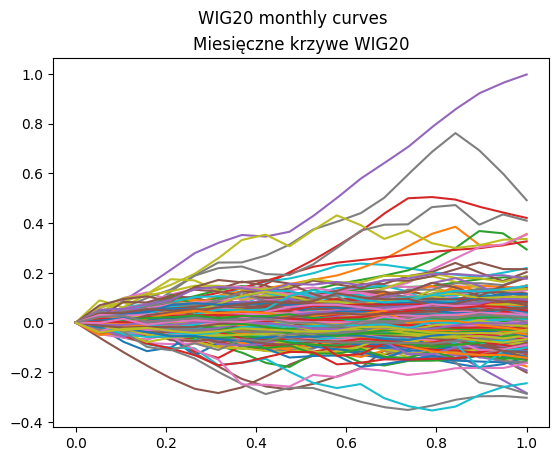

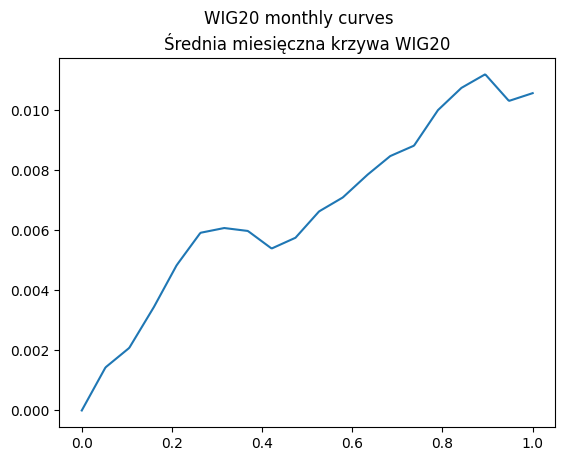

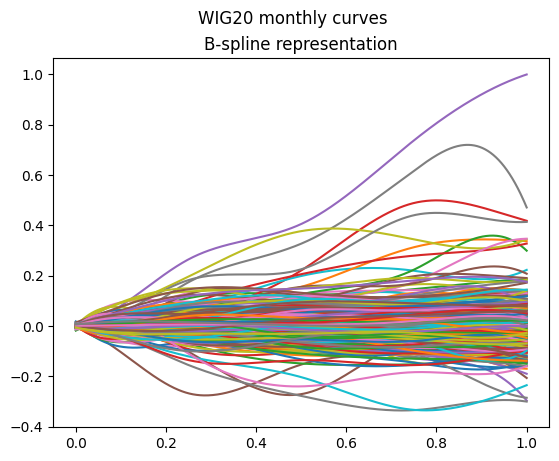

[[ 0.02130745  0.0145445 ]
 [-0.00761503 -0.00342859]
 [ 0.11849612  0.0186672 ]
 [ 0.29169369 -0.06886426]
 [ 0.54568097 -0.06640567]
 [-0.12487784 -0.10360181]
 [ 0.10994642  0.02438604]
 [ 0.41328138 -0.05249255]
 [-0.07252843  0.03655354]
 [ 0.15593415  0.01428891]]


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfda

from skfda import FDataGrid
from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.dim_reduction import FPCA

# 1. Wczytanie danych
df = pd.read_csv("wig20_d.csv", parse_dates=True)
df.columns = ['Date','Open', 'High', 'Low', 'Close', 'Volume']
df["Date"] = pd.to_datetime(df["Date"])
# df.head()
df = df.sort_values("Date").reset_index(drop=True)

df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df = df.dropna(subset=["Close"])
print(df.head())

# 2. Grupowanie po miesiącach
df["year_month"] = df["Date"].dt.to_period("M")

def resample_curve(y, n_points=20):
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, n_points)
    return np.interp(x_new, x_old, y)

curves = []
labels = []

for period, g in df.groupby("year_month"):
    y = g["Close"].values
    if len(y) < 10:
        continue
    
    # skumulowana względna zmiana od początku miesiąca
    y_norm = y / y[0] - 1
    
    curves.append(resample_curve(y_norm, n_points=20))
    labels.append(str(period))

curves = np.array(curves)

# 3. FDataGrid
grid_points = np.linspace(0, 1, 20)
fd = FDataGrid(
    data_matrix=curves,
    grid_points=grid_points,
    sample_names=labels,
    dataset_name="WIG20 monthly curves"
)

# 4. Wykres krzywych
fd.plot()
plt.title("Miesięczne krzywe WIG20")
plt.show()

# 5. Średnia funkcjonalna
fd.mean().plot()
plt.title("Średnia miesięczna krzywa WIG20")
plt.show()

# 6. Reprezentacja bazowa
basis = BSplineBasis(domain_range=(0, 1), n_basis=7, order=4)
fd_basis = fd.to_basis(basis)

fd_basis.plot()
plt.title("B-spline representation")
plt.show()

# 7. FPCA
fpca = FPCA(n_components=2)
scores = fpca.fit_transform(fd)

print(scores[:10])

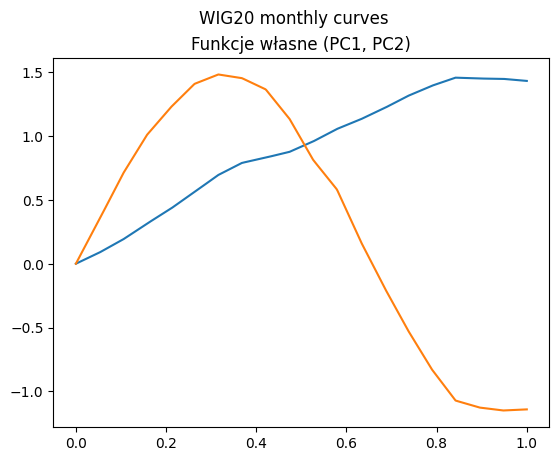

In [59]:
fpca.components_.plot()
plt.title("Funkcje własne (PC1, PC2)")
plt.show()

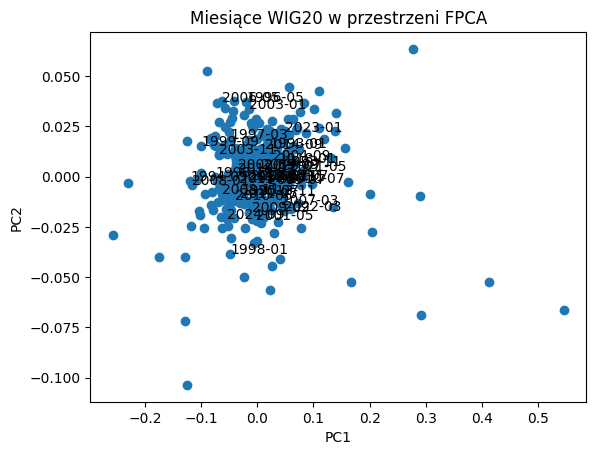

In [60]:
import matplotlib.pyplot as plt

plt.scatter(scores[:, 0], scores[:, 1])

for i, label in enumerate(labels):
    if i % 10 == 0:  # żeby nie było za gęsto
        plt.text(scores[i, 0], scores[i, 1], label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Miesiące WIG20 w przestrzeni FPCA")
plt.show()

In [61]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(scores)

In [62]:
dist = np.linalg.norm(scores, axis=1)

In [63]:
import numpy as np
import pandas as pd

scores_df = pd.DataFrame(scores, columns=["PC1", "PC2"])
scores_df["month"] = labels
scores_df["norm"] = np.linalg.norm(scores, axis=1)

print("Największe PC1:")
print(scores_df.nlargest(5, "PC1")[["month", "PC1", "PC2", "norm"]])

print("\nNajmniejsze PC1:")
print(scores_df.nsmallest(5, "PC1")[["month", "PC1", "PC2", "norm"]])

print("\nNajwiększe PC2:")
print(scores_df.nlargest(5, "PC2")[["month", "PC1", "PC2", "norm"]])

print("\nNajmniejsze PC2:")
print(scores_df.nsmallest(5, "PC2")[["month", "PC1", "PC2", "norm"]])

print("\nNajbardziej nietypowe miesiące:")
print(scores_df.nlargest(10, "norm")[["month", "PC1", "PC2", "norm"]])

Największe PC1:
      month       PC1       PC2      norm
4   1993-05  0.545681 -0.066406  0.549707
7   1993-08  0.413281 -0.052493  0.416602
3   1993-04  0.291694 -0.068864  0.299712
27  1995-04  0.289733 -0.009458  0.289888
18  1994-07  0.277841  0.063483  0.285002

Najmniejsze PC1:
       month       PC1       PC2      norm
17   1994-06 -0.256847 -0.029200  0.258501
189  2008-10 -0.230428 -0.003030  0.230448
326  2020-03 -0.174599 -0.039827  0.179083
15   1994-04 -0.129219 -0.071654  0.147756
223  2011-08 -0.129034 -0.040198  0.135150

Największe PC2:
       month       PC1       PC2      norm
18   1994-07  0.277841  0.063483  0.285002
14   1994-03 -0.088794  0.052736  0.103273
129  2003-10  0.055798  0.044416  0.071318
195  2009-04  0.110052  0.042698  0.118045
45   1996-10 -0.041489  0.037490  0.055918

Najmniejsze PC2:
      month       PC1       PC2      norm
5   1993-06 -0.124878 -0.103602  0.162258
15  1994-04 -0.129219 -0.071654  0.147756
3   1993-04  0.291694 -0.068864  0.29

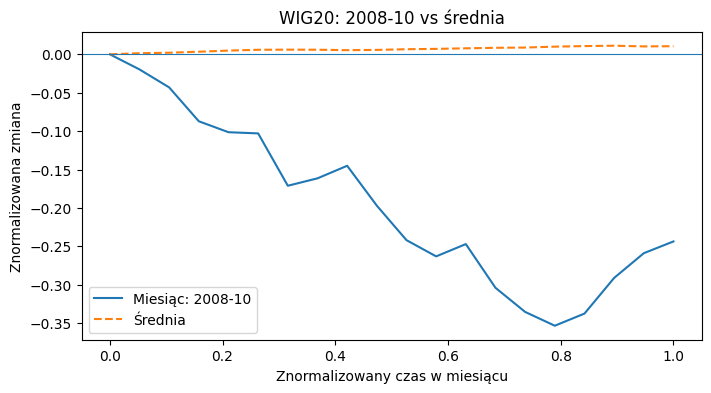

month     2008-10
PC1     -0.230428
PC2      -0.00303
norm     0.230448
Name: 189, dtype: object


In [65]:
import matplotlib.pyplot as plt

grid = np.array(fd.grid_points[0])
data = fd.data_matrix[..., 0]
mean_curve = fd.mean().data_matrix[0, :, 0]

def plot_month_vs_mean(month_label):
    idx = labels.index(month_label)
    curve = data[idx]

    plt.figure(figsize=(8, 4))
    plt.plot(grid, curve, label=f"Miesiąc: {month_label}")
    plt.plot(grid, mean_curve, label="Średnia", linestyle="--")
    plt.axhline(0, linewidth=0.8)
    plt.xlabel("Znormalizowany czas w miesiącu")
    plt.ylabel("Znormalizowana zmiana")
    plt.title(f"WIG20: {month_label} vs średnia")
    plt.legend()
    plt.show()

    print(scores_df.loc[idx, ["month", "PC1", "PC2", "norm"]])
    
plot_month_vs_mean("2008-10")

In [66]:
def describe_month(month_label):
    idx = labels.index(month_label)
    row = scores_df.loc[idx]

    print(f"Miesiąc: {row['month']}")
    print(f"PC1 = {row['PC1']:.4f}")
    print(f"PC2 = {row['PC2']:.4f}")
    print(f"Norma = {row['norm']:.4f}")

    if row["PC1"] > 0.15:
        print("Interpretacja PC1: wyraźnie wzrostowy miesiąc.")
    elif row["PC1"] < -0.15:
        print("Interpretacja PC1: wyraźnie słaby lub spadkowy miesiąc.")
    else:
        print("Interpretacja PC1: miesiąc bliski przeciętnemu trendowi.")

    if row["PC2"] > 0.03:
        print("Interpretacja PC2: mocniejszy początek miesiąca, słabsza końcówka.")
    elif row["PC2"] < -0.03:
        print("Interpretacja PC2: słabszy początek miesiąca, mocniejsza końcówka.")
    else:
        print("Interpretacja PC2: brak silnej asymetrii początku i końca miesiąca.")

In [67]:
def plot_selected_months(month_list):
    plt.figure(figsize=(10, 5))
    for month_label in month_list:
        idx = labels.index(month_label)
        plt.plot(grid, data[idx], label=month_label)

    plt.plot(grid, mean_curve, color="black", linestyle="--", linewidth=2, label="Średnia")
    plt.axhline(0, linewidth=0.8)
    plt.xlabel("Znormalizowany czas w miesiącu")
    plt.ylabel("Znormalizowana zmiana")
    plt.title("Wybrane miesiące WIG20 na tle średniej")
    plt.legend()
    plt.show()

In [68]:
top_pc1 = scores_df.nlargest(3, "PC1")["month"].tolist()
bottom_pc1 = scores_df.nsmallest(3, "PC1")["month"].tolist()
top_pc2 = scores_df.nlargest(3, "PC2")["month"].tolist()
bottom_pc2 = scores_df.nsmallest(3, "PC2")["month"].tolist()

selected = list(dict.fromkeys(top_pc1 + bottom_pc1 + top_pc2 + bottom_pc2))
print(selected)

['1993-05', '1993-08', '1993-04', '1994-06', '2008-10', '2020-03', '1994-07', '1994-03', '2003-10', '1993-06', '1994-04']


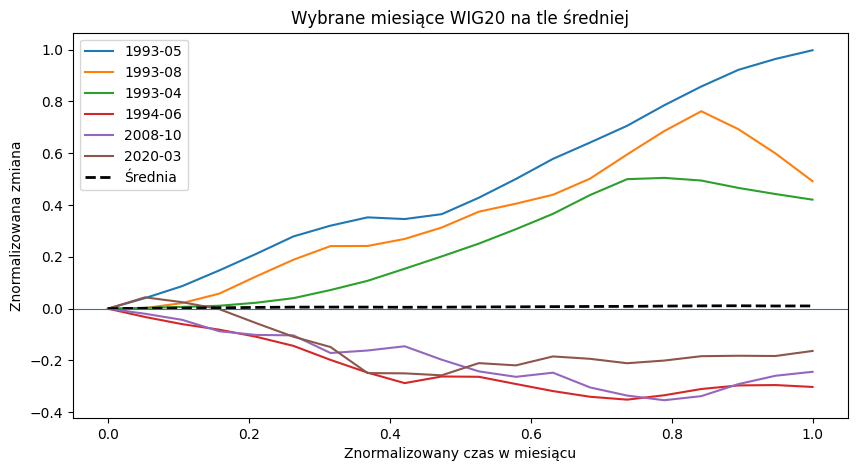

In [69]:
plot_selected_months(selected[:6])

In [70]:
scores_df_sorted = scores_df.sort_values("norm", ascending=False)
print(scores_df_sorted.head(20))

          PC1       PC2    month      norm
4    0.545681 -0.066406  1993-05  0.549707
7    0.413281 -0.052493  1993-08  0.416602
3    0.291694 -0.068864  1993-04  0.299712
27   0.289733 -0.009458  1995-04  0.289888
18   0.277841  0.063483  1994-07  0.285002
17  -0.256847 -0.029200  1994-06  0.258501
189 -0.230428 -0.003030  2008-10  0.230448
11   0.205096 -0.027745  1993-12  0.206964
13   0.201506 -0.008510  1994-02  0.201685
326 -0.174599 -0.039827  2020-03  0.179083
12   0.167529 -0.052229  1994-01  0.175482
5   -0.124878 -0.103602  1993-06  0.162258
36   0.161018 -0.002932  1996-01  0.161045
9    0.155934  0.014289  1993-10  0.156587
15  -0.129219 -0.071654  1994-04  0.147756
108  0.140721  0.031376  2002-01  0.144176
334  0.139030  0.022546  2020-11  0.140846
223 -0.129034 -0.040198  2011-08  0.135150
105  0.133926 -0.015332  2001-10  0.134800
85   0.132009  0.009182  2000-02  0.132328


In [71]:
scores_df.to_csv("wig20_fpca_months.csv", index=False)

In [72]:
reconstructed = fpca.inverse_transform(scores)
recon_data = reconstructed.data_matrix[..., 0]

def plot_month_with_reconstruction(month_label):
    idx = labels.index(month_label)

    plt.figure(figsize=(8, 4))
    plt.plot(grid, data[idx], label="Oryginał")
    plt.plot(grid, recon_data[idx], label="Rekonstrukcja FPCA", linestyle="--")
    plt.axhline(0, linewidth=0.8)
    plt.title(f"{month_label}: oryginał vs rekonstrukcja")
    plt.legend()
    plt.show()

Analiza FPCA miesięcznych przebiegów indeksu WIG20 wykazała, że pierwsza składowa główna odpowiada za siłę trendu w danym miesiącu, natomiast druga składowa opisuje asymetrię przebiegu, tj. relację między zachowaniem indeksu na początku i końcu miesiąca.
Największe wartości pierwszej składowej obserwowane są w początkowych latach funkcjonowania indeksu, co wskazuje na odmienny reżim dynamiki rynku. Z kolei miesiące takie jak październik 2008 oraz marzec 2020 stanowią wyraźne obserwacje odstające, odpowiadające okresom kryzysowym.

In [77]:
window = 60
step = 5
n_points = 30

def resample(y, n_points):
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, n_points)
    return np.interp(x_new, x_old, y)

curves = []

for i in range(0, len(df) - window, step):
    y = df["Close"].values[i:i+window]
    y = y / y[0] - 1
    curves.append(resample(y, n_points))

curves = np.array(curves)

fd = FDataGrid(
    data_matrix=curves,
    grid_points=np.linspace(0, 1, n_points)
)

To, co zrobiłeś, od A do Z, to w gruncie rzeczy **analiza danych giełdowych w ujęciu functional data analysis (FDA)** z użyciem **FPCA**. Precyzyjniej:

# Co zrobiłeś krok po kroku

## 1. Wziąłeś klasyczny szereg czasowy WIG20

Miałeś dane typu:

* data,
* wartość indeksu `Close`.

Na tym etapie to jeszcze był zwykły szereg czasowy.

---

## 2. Zamieniłeś jeden szereg na zbiór krzywych

To był kluczowy krok.

Nie analizowałeś już całego WIG20 jako jednej długiej trajektorii, tylko zrobiłeś:

* **jedna obserwacja = jeden miesiąc**,
* w każdym miesiącu miałeś przebieg indeksu w czasie.

Czyli z punktu widzenia FDA utworzyłeś próbę funkcji:
$$
X_1(t), X_2(t), \dots, X_n(t)
$$
gdzie każda funkcja opisuje jeden miesiąc.

To jest właśnie przejście:
**time series (\to) sample of curves**.

---

## 3. Znormalizowałeś każdą krzywą

U Ciebie było coś w rodzaju:
$$
y_{\text{norm}}(t) = \frac{y(t)}{y(0)} - 1
$$

Czyli każdy miesiąc zaczynał się od 0.

To oznacza, że nie analizowałeś bezwzględnego poziomu indeksu, tylko:

* względną zmianę w trakcie miesiąca,
* kształt ruchu,
* siłę wzrostu/spadku.

To bardzo ważne, bo od tego momentu interpretacja dotyczy **przebiegu miesiąca**, a nie poziomu WIG20.

---

## 4. Ujednoliciłeś długość obserwacji

Miesiące mają różną liczbę sesji, więc zrobiłeś interpolację / resampling do stałej liczby punktów, np. 20.

To dało wspólną siatkę:
$$
t_1, t_2, \dots, t_m
$$

Dzięki temu każda miesięczna krzywa była opisana na tej samej dziedzinie ($$0,1$$).

To jest standardowy krok w FDA, bo funkcje muszą być porównywalne na wspólnej domenie.

---

## 5. Zbudowałeś obiekt funkcjonalny `FDataGrid`

Czyli formalnie zapisałeś dane jako zbiór funkcji dyskretnych.

To już nie był zwykły `DataFrame`, tylko reprezentacja typu:

* obserwacje = funkcje,
* argument = znormalizowany czas w miesiącu,
* wartości = znormalizowane zmiany WIG20.

To jest właściwy wejściowy obiekt do analizy funkcjonalnej.

---

## 6. Obejrzałeś cały zbiór krzywych

Narysowałeś wszystkie miesięczne trajektorie.

To dało pierwszą odpowiedź na pytanie:

* czy miesiące są podobne,
* czy są outliery,
* czy średnio rynek rośnie czy spada,
* czy są okresy ekstremalne.

Już na tym etapie widać było, że:

* większość miesięcy jest umiarkowana,
* kilka miesięcy jest skrajnych,
* niektóre przebiegi są bardzo nietypowe.

---

## 7. Policzyłeś średnią funkcjonalną

Czyli:
$$
\mu(t)
$$

To jest przeciętny miesięczny przebieg WIG20 po normalizacji.

Interpretacja:

* jak „średnio” zachowuje się indeks w trakcie miesiąca.

U Ciebie średnia była lekko rosnąca, więc przeciętny miesiąc miał niewielki dodatni trend.

---

## 8. Przeszedłeś do reprezentacji bazowej B-spline

Czyli zamieniłeś dane z siatki dyskretnej na gładką reprezentację w bazie splajnów.

Formalnie:
$$
X_i(t) \approx \sum_{k=1}^K c_{ik}\phi_k(t)
$$

To znaczy:

* każda miesięczna krzywa została przybliżona kombinacją funkcji bazowych,
* wygładziłeś dane,
* usunąłeś część szumu,
* dostałeś bardziej regularny opis kształtu.

To był etap:
**dane dyskretne (\to) gładkie funkcje bazowe**.

---

## 9. Zastosowałeś FPCA

To jest najważniejszy element całej analizy.

FPCA znajduje:

* średnią funkcję (\mu(t)),
* główne tryby zmienności (\phi_1(t), \phi_2(t), \dots),
* współrzędne każdej krzywej względem tych trybów.

Czyli:
$$
X_i(t) \approx \mu(t) + c_{i1}\phi_1(t) + c_{i2}\phi_2(t) + \dots
$$

To jest funkcjonalny odpowiednik klasycznego PCA.

---

## 10. Otrzymałeś scores

Czyli dla każdego miesiąca dostałeś liczby:

* `PC1`,
* `PC2`.

To są współrzędne miesiąca w nowej przestrzeni niskowymiarowej.

One nie są „wynikiem same w sobie”, tylko opisują:

* jak bardzo dany miesiąc odbiega od średniej,
* w jakim kierunku,
* jakiego rodzaju miał kształt.

---

## 11. Zinterpretowałeś funkcje własne

To był moment, w którym analiza stała się sensowna merytorycznie.

U Ciebie wyszło mniej więcej:

* **PC1**: ogólna siła trendu miesiąca,
* **PC2**: asymetria przebiegu, czyli początek vs koniec miesiąca.

To znaczy:

* wysokie PC1 → mocny wzrost,
* niskie PC1 → słabość / spadek,
* dodatnie PC2 → mocniejszy początek, słabszy koniec,
* ujemne PC2 → słabszy początek, mocniejszy koniec.

---

## 12. Zrobiłeś mapę miesięcy w przestrzeni FPCA

Czyli rozrzut punktów `(PC1, PC2)`.

To dało:

* grupowanie podobnych miesięcy,
* wykrycie nietypowych miesięcy,
* możliwość interpretacji geometrycznej.

W tej przestrzeni:

* punkty blisko zera → miesiące przeciętne,
* punkty daleko → miesiące nietypowe,
* prawa/lewa strona → wzrost/spadek,
* góra/dół → różny rozkład ruchu w czasie.

---

## 13. Wykryłeś outliery

Na podstawie:

* dużego `|PC1|`,
* dużego `|PC2|`,
* dużej normy wektora `(PC1, PC2)`.

Wyszły Ci konkretne miesiące:

* 1993-05,
* 1993-08,
* 2008-10,
* 2020-03,
  itd.

Czyli wykryłeś miesiące skrajne względem całej próby.

---

## 14. Porównałeś konkretne miesiące ze średnią

To jest już etap interpretacji ekonomicznej.

Narysowałeś:

* wybrany miesiąc,
* średnią funkcjonalną,
* kilka skrajnych miesięcy razem.

Dzięki temu można było powiedzieć nie tylko:
„ten miesiąc ma duże PC1”,
ale:
„ten miesiąc to silny wzrost / crash / odbicie / wyhamowanie”.

---

# Jak to nazwać jednym zdaniem

Najuczciwiej:

> Przekształciłeś dzienne dane WIG20 do postaci zbioru miesięcznych krzywych, znormalizowałeś je, wygładziłeś, a następnie przeprowadziłeś funkcjonalną analizę głównych składowych (FPCA), aby opisać dominujące wzorce zmian i zidentyfikować miesiące nietypowe.

---

# Jakie dziedziny tu się łączą

To, co zrobiłeś, leży na styku:

* **analizy szeregów czasowych**
  bo punktem wyjścia był indeks giełdowy,

* **functional data analysis**
  bo zamieniłeś dane na zbiór funkcji,

* **redukcji wymiaru / PCA**
  bo użyłeś FPCA,

* **analizy eksploracyjnej**
  bo interpretowałeś wzorce i outliery.

---

# Czym to nie jest

To nie jest jeszcze:

* model prognostyczny,
* model ARIMA/GARCH,
* klasyczna analiza ekonomiczna stóp zwrotu,
* testowanie hipotez rynkowych.

To jest przede wszystkim:
**opisowa i geometryczna analiza struktury miesięcznych przebiegów WIG20**.

---

# Najkrótsza etykieta do sprawozdania

Możesz to nazwać tak:

**Funkcjonalna analiza miesięcznych trajektorii indeksu WIG20 z użyciem baz B-splajnowych i FPCA**

albo trochę prościej:

**Analiza functional data dla miesięcznych przebiegów WIG20**

---

# Schemat całej procedury

W bardzo skróconej formie:

1. wczytanie danych WIG20,
2. podział na miesiące,
3. normalizacja każdej trajektorii,
4. resampling do wspólnej siatki,
5. konstrukcja `FDataGrid`,
6. wyznaczenie średniej funkcjonalnej,
7. wygładzanie / reprezentacja w bazie B-splajnów,
8. FPCA,
9. analiza scores i funkcji własnych,
10. interpretacja konkretnych miesięcy i obserwacji odstających.

---

Jeśli chcesz, mogę Ci teraz z tego zrobić **ładny opis metodologii do sprawozdania**, takim bardziej akademickim stylem.


        Date   Open   High    Low  Close   Volume
0 1991-04-16  100.0  100.0  100.0  100.0    325.0
1 1991-04-23   95.7   95.7   95.7   95.7   5905.0
2 1991-04-30   93.5   93.5   93.5   93.5   7162.0
3 1991-05-14   92.9   92.9   92.9   92.9  18300.0
4 1991-05-21   95.5   95.5   95.5   95.5  14750.0


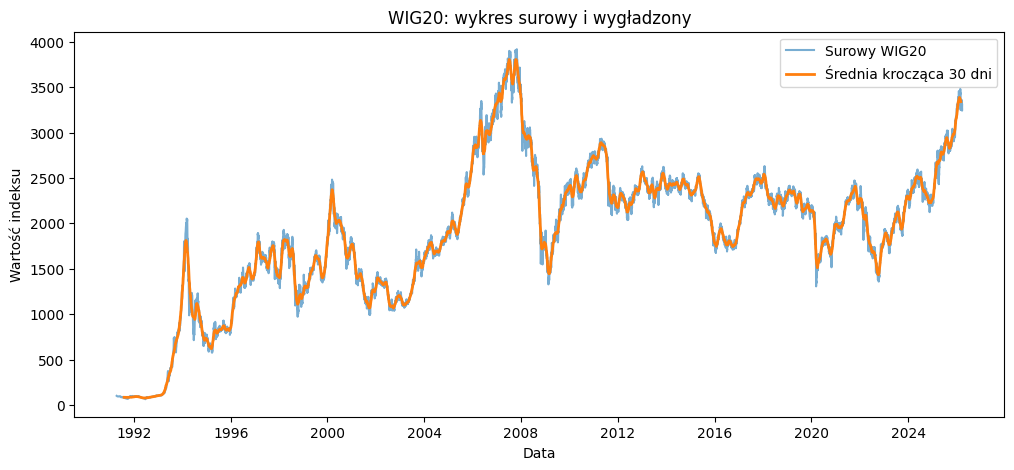

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("wig20_d.csv", parse_dates=True)
df.columns = ['Date','Open', 'High', 'Low', 'Close', 'Volume']
df["Date"] = pd.to_datetime(df["Date"])
# df.head()
df = df.sort_values("Date").reset_index(drop=True)

df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df = df.dropna(subset=["Close"])
print(df.head())

df["MA30"] = df["Close"].rolling(30, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"], label="Surowy WIG20", alpha=0.6)
plt.plot(df["Date"], df["MA30"], label="Średnia krocząca 30 dni", linewidth=2)
plt.title("WIG20: wykres surowy i wygładzony")
plt.xlabel("Data")
plt.ylabel("Wartość indeksu")
plt.legend()
plt.show()

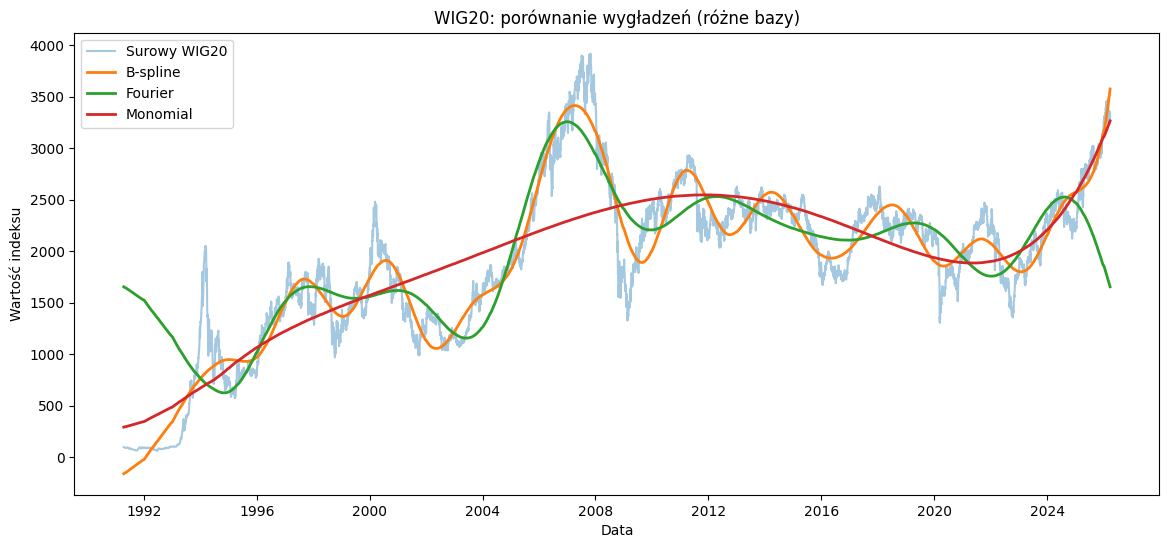

In [81]:
import numpy as np
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.representation.basis import (
    BSplineBasis,
    FourierBasis,
    MonomialBasis
)

y = df["Close"].values
x = np.linspace(0, 1, len(y))

fd = FDataGrid(data_matrix=[y], grid_points=x)

# --- B-spline ---
basis_bspline = BSplineBasis(domain_range=(0, 1), n_basis=25, order=4)
fd_bspline = fd.to_basis(basis_bspline)
y_bspline = fd_bspline(x).reshape(-1)

# --- Fourier ---
basis_fourier = FourierBasis(domain_range=(0, 1), n_basis=15)
fd_fourier = fd.to_basis(basis_fourier)
y_fourier = fd_fourier(x).reshape(-1)

# --- Monomial (UWAGA: niestabilne przy dużym stopniu) ---
basis_monomial = MonomialBasis(domain_range=(0, 1), n_basis=6)
fd_monomial = fd.to_basis(basis_monomial)
y_monomial = fd_monomial(x).reshape(-1)

# --- Wykres ---
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], y, label="Surowy WIG20", alpha=0.4)

plt.plot(df["Date"], y_bspline, label="B-spline", linewidth=2)
plt.plot(df["Date"], y_fourier, label="Fourier", linewidth=2)
plt.plot(df["Date"], y_monomial, label="Monomial", linewidth=2)

plt.title("WIG20: porównanie wygładzeń (różne bazy)")
plt.xlabel("Data")
plt.ylabel("Wartość indeksu")
plt.legend()
plt.show()